In [1]:
# Base imports
import os
import pickle

# Compute imports
import numpy as np
import pandas as pd
import scipy
from tqdm.notebook import tqdm, trange

# Plotting imports
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
from matplotlib import pyplot as plt
import seaborn as sns
from plotly import express as px

# ML import
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error, median_absolute_error
from sklearn.metrics.pairwise import cosine_similarity
from pyphylon.util import load_config

# Figure 1

## Figure 1A

made using Biorender

## Figure 1B

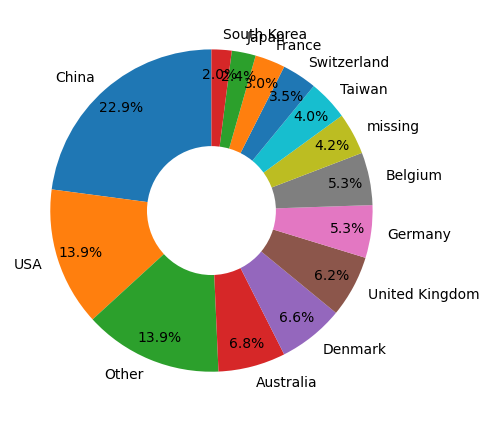

In [2]:
metadata = pd.read_csv('/mnt/craig/pan_phylon/P_aeruginosa/data/interim/2d_ncbi_enriched_metadata.csv', index_col=0, dtype='str')

# cleaning up metadata isolation sources
metadata['isolation_country'] = metadata['isolation_country'].replace({
    'not applicable': 'missing',
    'Unknown': 'missing',
    'unknown': 'missing',
    'not collected': 'missing',
    'Not applicable': 'missing',
    ' missing': 'missing',
    'Tokyo': 'Japan',
    'Viet Nam': 'Vietnam',
    'Hong Kong': 'China',
    'Puerto Rico': 'USA'
})

s = metadata.isolation_country.value_counts()

# Keep >30 or 'missing'
keep = s[(s > 25) | (s.index == 'missing')]

# Sum the rest into "Other"
other = s[~s.index.isin(keep.index)].sum()

plot_data = pd.concat([keep, pd.Series({'Other': other})])
plot_data = plot_data.sort_values(ascending=False)

labels = plot_data.index.tolist()
values = plot_data.values.tolist()

plt.figure(figsize=(5,5))

plt.pie(values,
        labels=labels,
        autopct='%1.1f%%',
        pctdistance=0.85,
        # explode=explode,
        startangle=90)

centre_circle = plt.Circle((0, 0), 0.4, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.tight_layout()
plt.show()

## Figure 1C

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


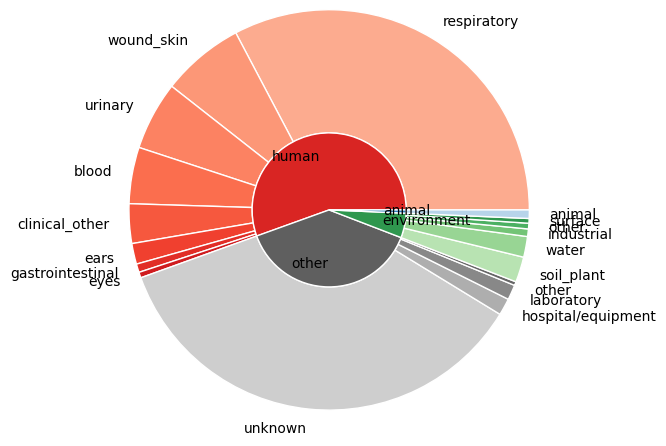

In [4]:
group_counts = metadata.isolation_source_l1.value_counts()
group_names = group_counts.index.values
group_size = group_counts.values

subgroup_names = []
subgroup_size = []

for g in group_names:
    sub_counts = metadata.loc[metadata.isolation_source_l1 == g, 'isolation_source_l2'].value_counts()
    subgroup_names += list(sub_counts.index.values)
    subgroup_size += list(sub_counts.values)

cmap_dict = {
    'human': plt.cm.Reds,
    'environment': plt.cm.Greens,
    'animal': plt.cm.Blues,
    'other': plt.cm.Greys
}

outer_colors = []
for g in group_names:
    n = metadata.loc[metadata['isolation_source_l1'] == g, 'isolation_source_l2'].nunique()
    cmap = cmap_dict.get(g, plt.cm.Purples)
    outer_colors += [cmap(0.3 + i*(0.5/max(n,1))) for i in range(n)]

inner_colors = [cmap_dict.get(g, plt.cm.Purples)(0.7) for g in group_names]

fig, ax = plt.subplots(figsize=(5,5))
ax.axis('equal')

mypie, _ = ax.pie(
    subgroup_size,
    radius=1.3,
    labels=subgroup_names,
    colors=outer_colors
)
plt.setp(mypie, width=0.8, edgecolor='white')

mypie2, _ = ax.pie(
    group_size,
    radius=1.3-0.8,
    labels=group_names,
    labeldistance=0.7,
    colors=inner_colors
)
plt.setp(mypie2, width=0.5, edgecolor='white')

plt.margins(0,0)
plt.show()

## Figure 1D

 made using Excel

## Figure 1E
Code for generation of Mash clustermap can be found in 2b_ncbi_mash_filtration_and_clustering.ipynb

# Figure 2
code for all three panels can be found in 3a_ncbi_extract_CAR_genomes.ipynb

# Figure 3

## Figure 3A
created using Illustrator

In [5]:
L_binarized = pd.read_csv("/mnt/craig/pan_phylon/P_aeruginosa/data/processed_ncbi/nmf-outputs/L_binarized.csv", index_col=0)
A_binarized = pd.read_csv("/mnt/craig/pan_phylon/P_aeruginosa/data/processed_ncbi/nmf-outputs/A_binarized.csv", index_col=0)

## Figure 3B

/mnt/craig/pan_phylon/P_aeruginosa/heera-jupyterlab/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/mnt/craig/pan_phylon/P_aeruginosa/heera-jupyterlab/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


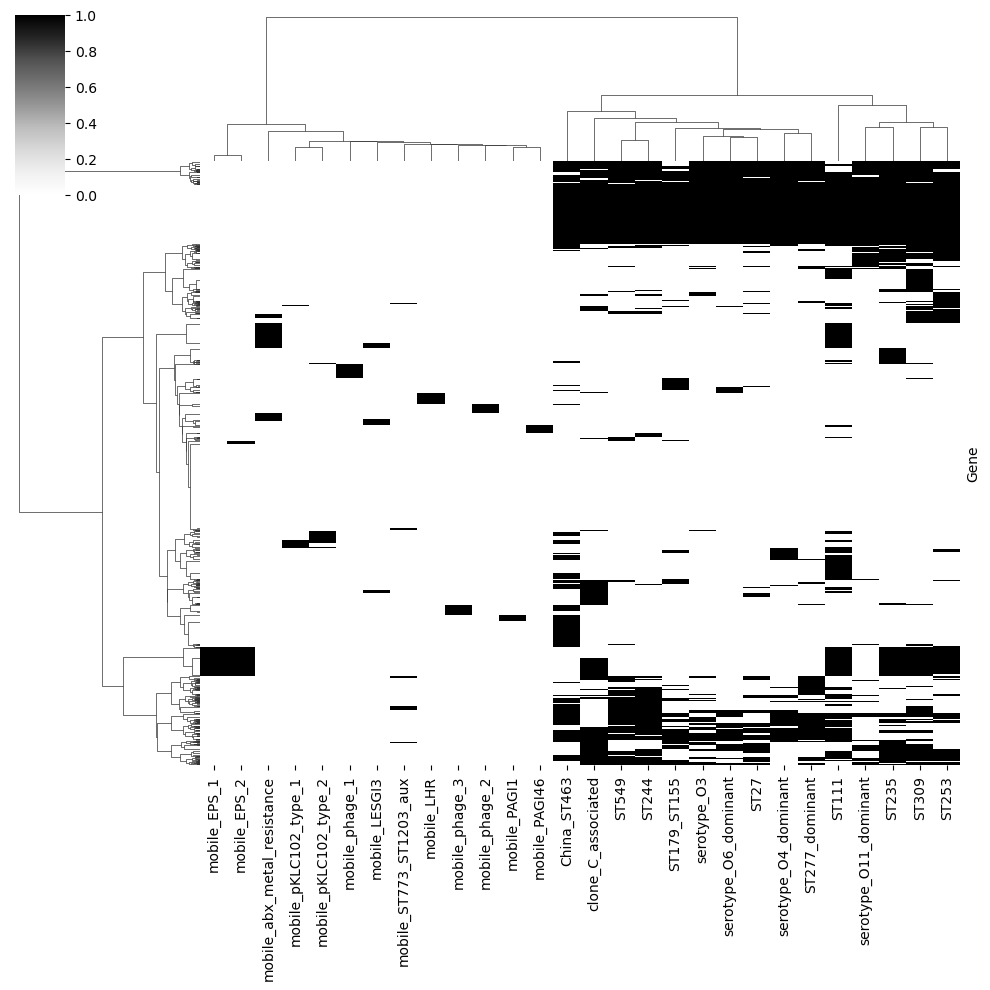

In [7]:
g_bin = sns.clustermap(L_binarized,
                       method='ward',
                       metric='euclidean', # metric must be euclidean for ward (even if binarized)
                       cmap='Greys',
                       yticklabels=False,
                       robust=True
                      )

  0%|          | 0/14 [00:00<?, ?it/s]

/mnt/craig/pan_phylon/P_aeruginosa/heera-jupyterlab/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/mnt/craig/pan_phylon/P_aeruginosa/heera-jupyterlab/lib/python3.12/site-packages/seaborn/matrix.py:615: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(0, max_dependent_coord * 1.05)


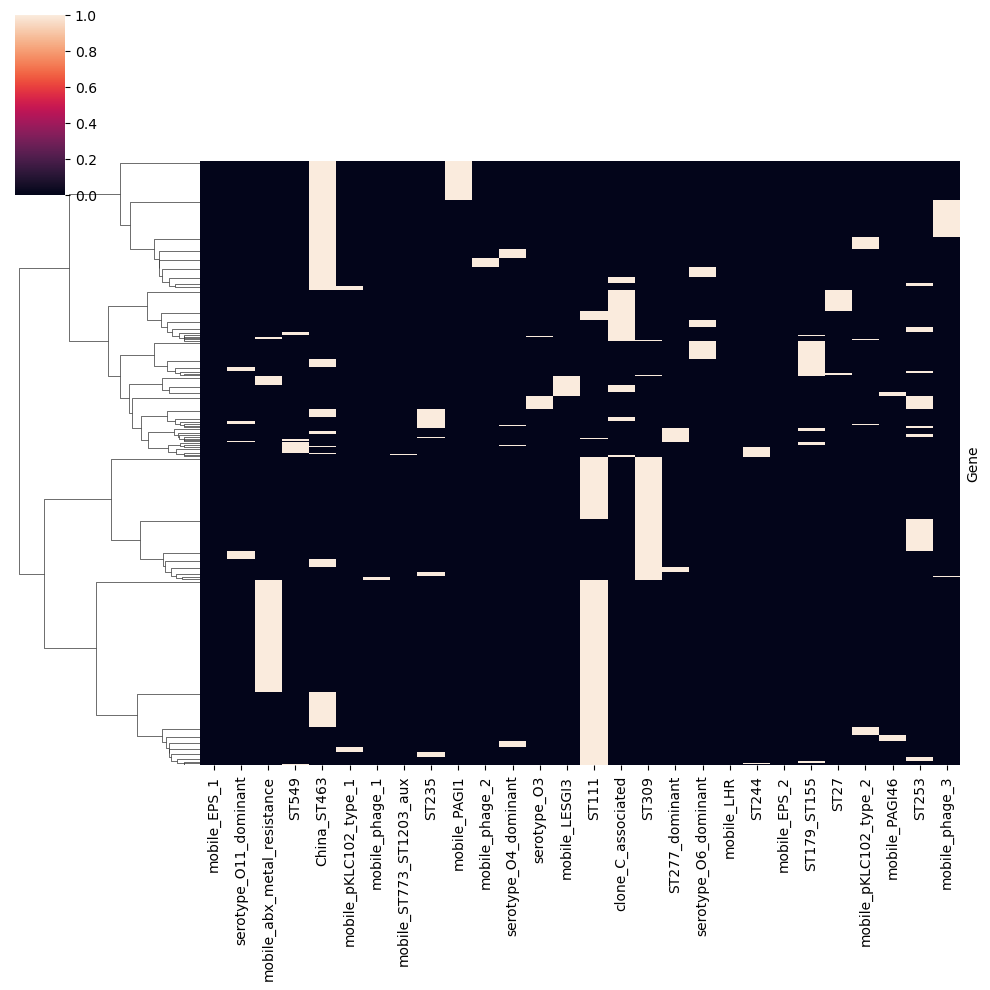

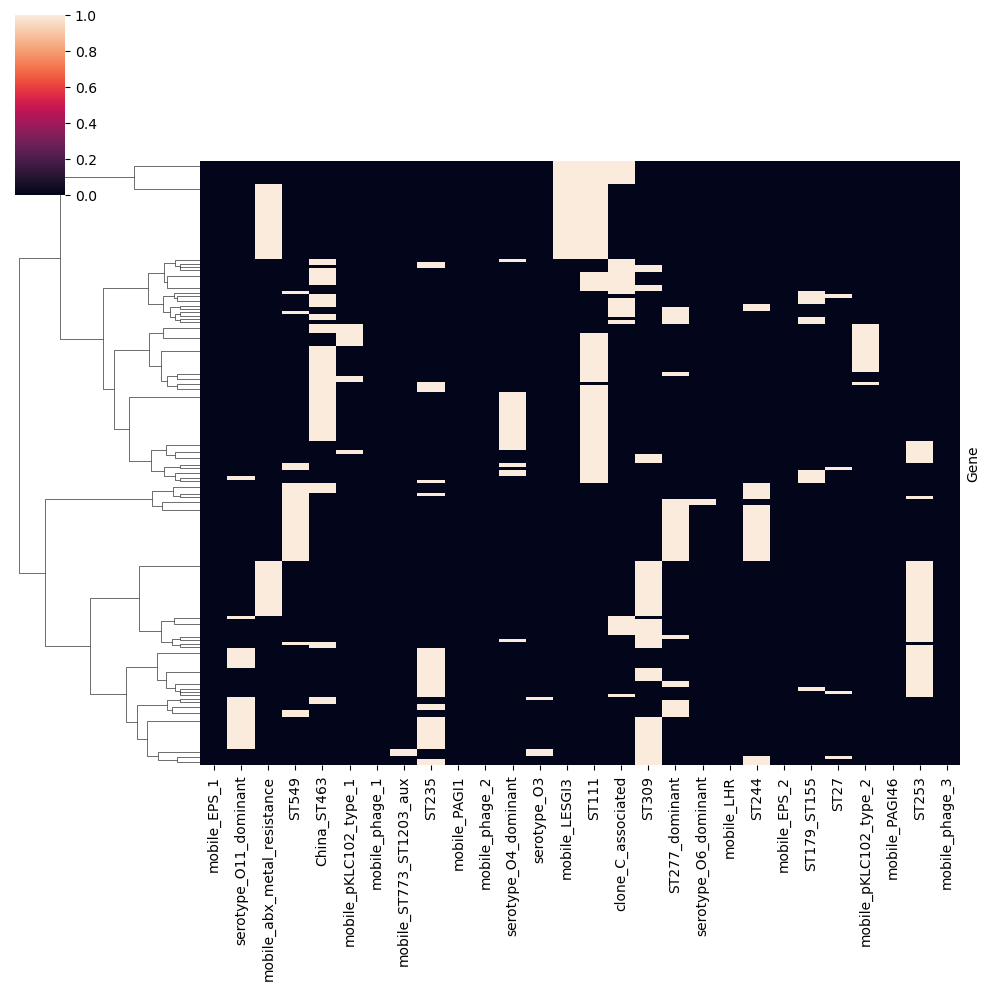

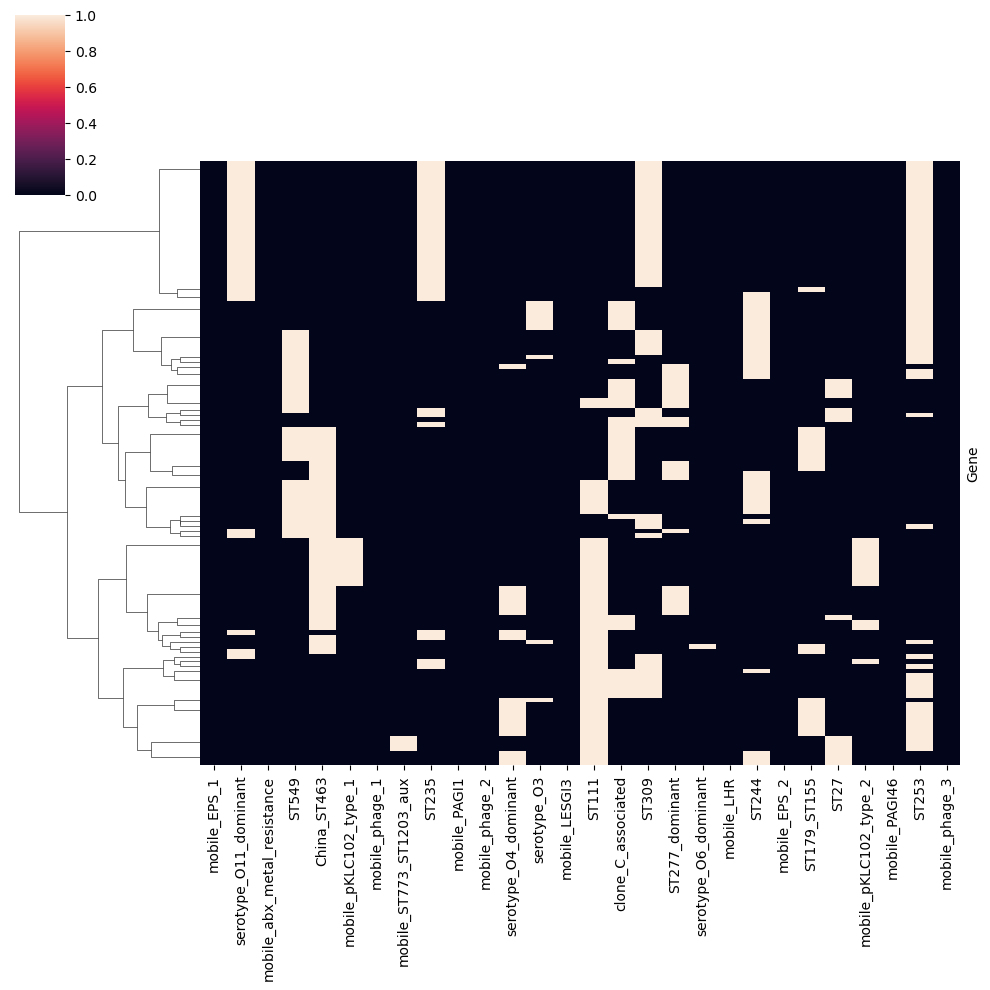

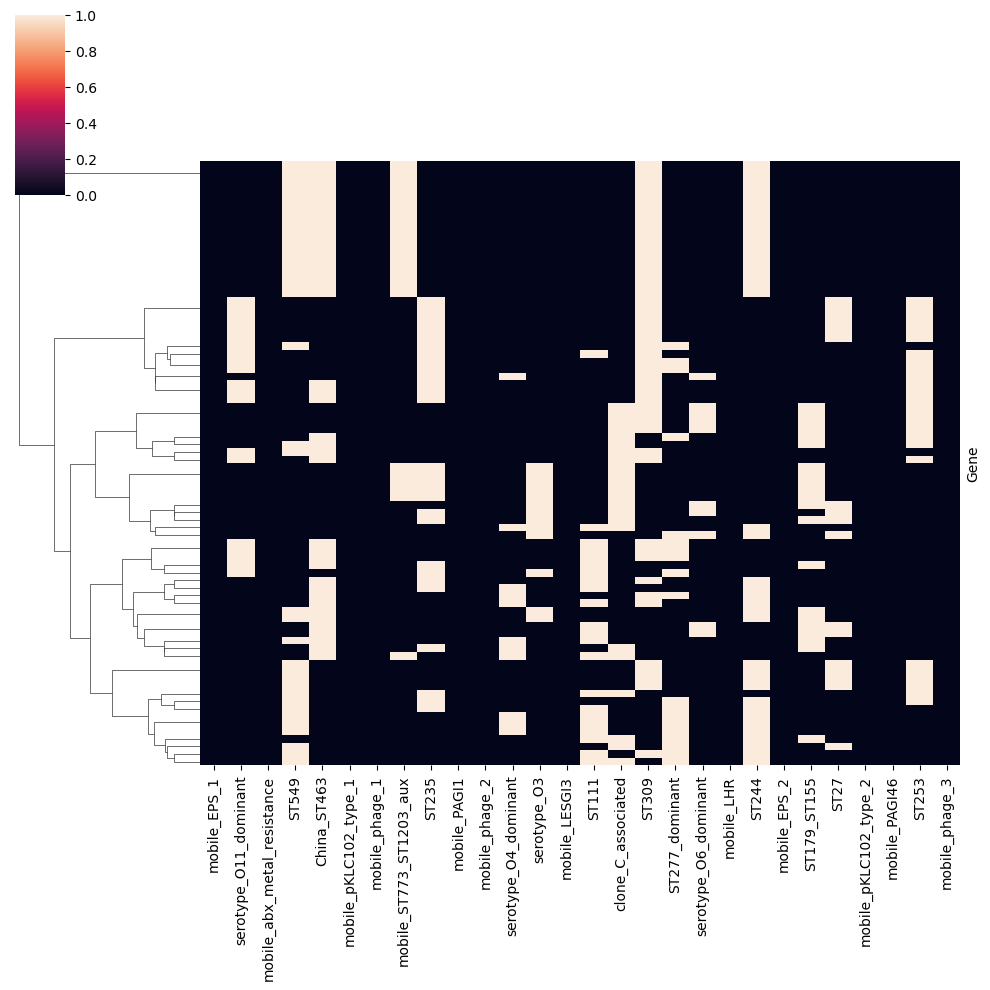

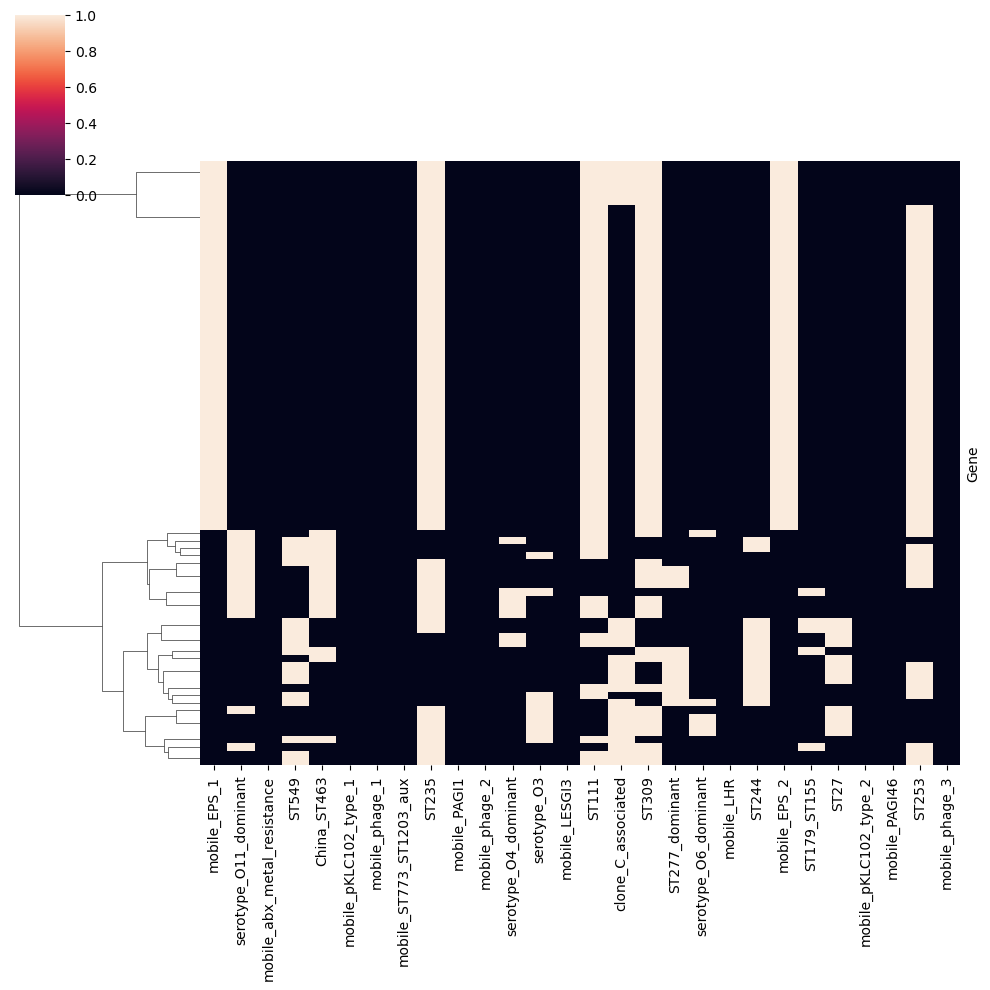

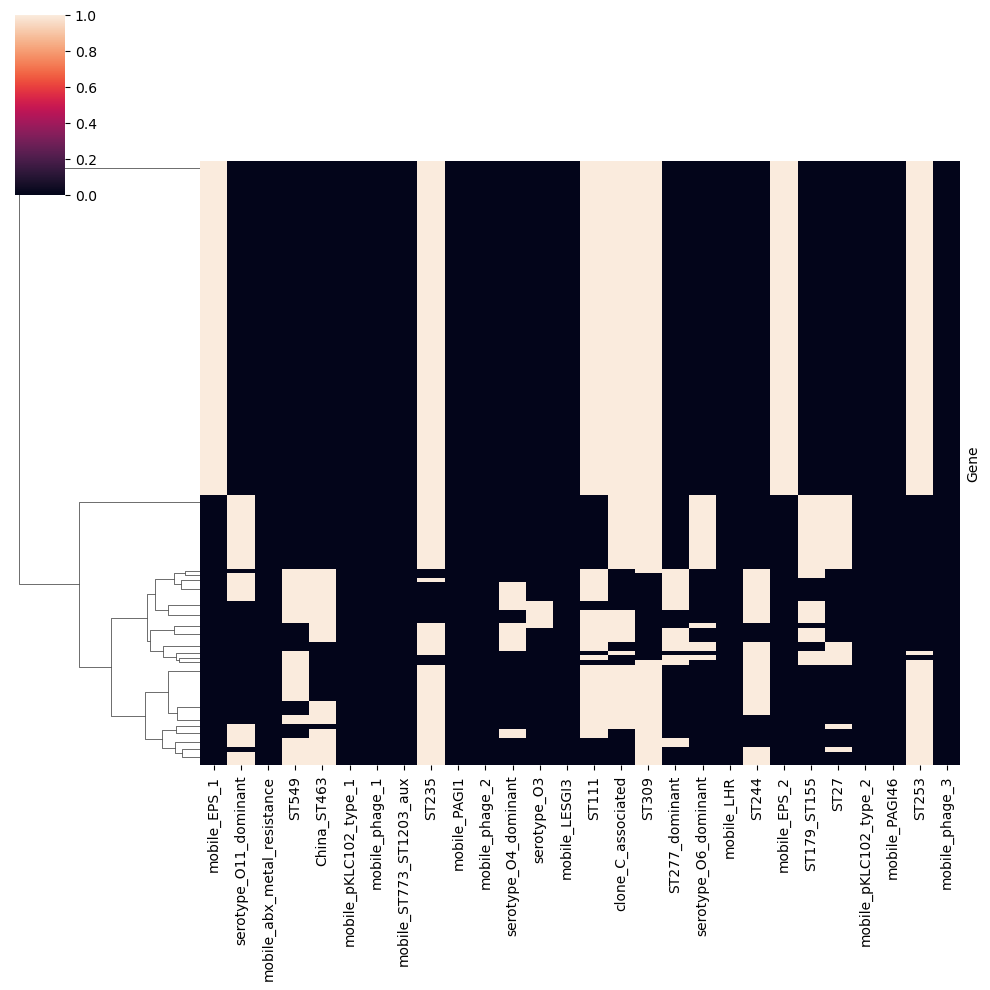

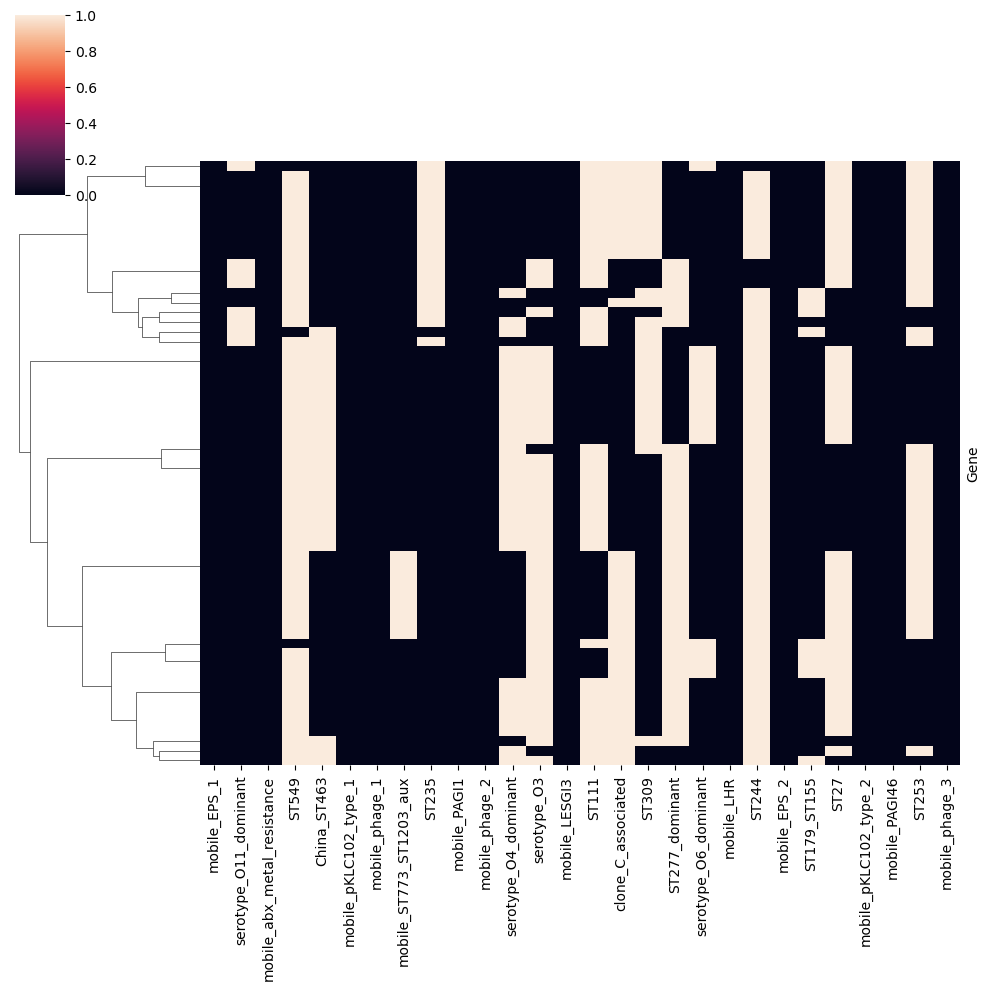

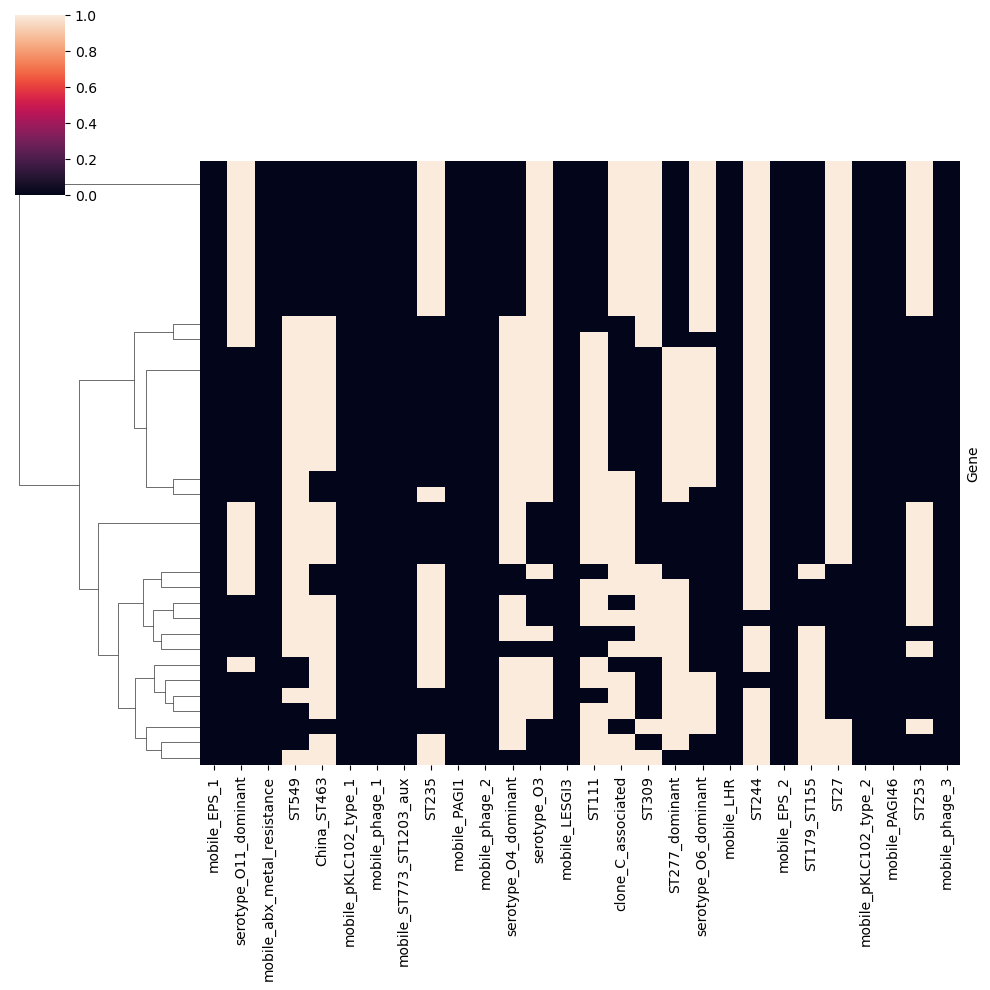

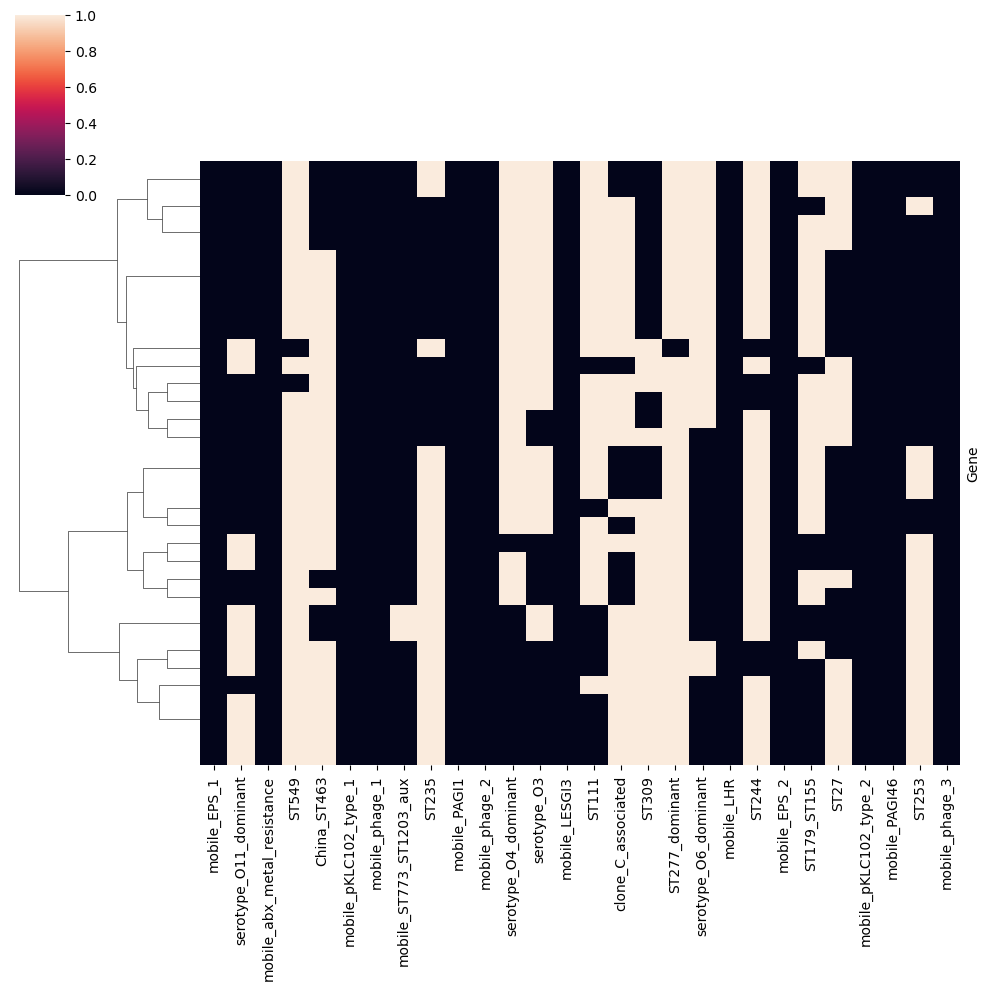

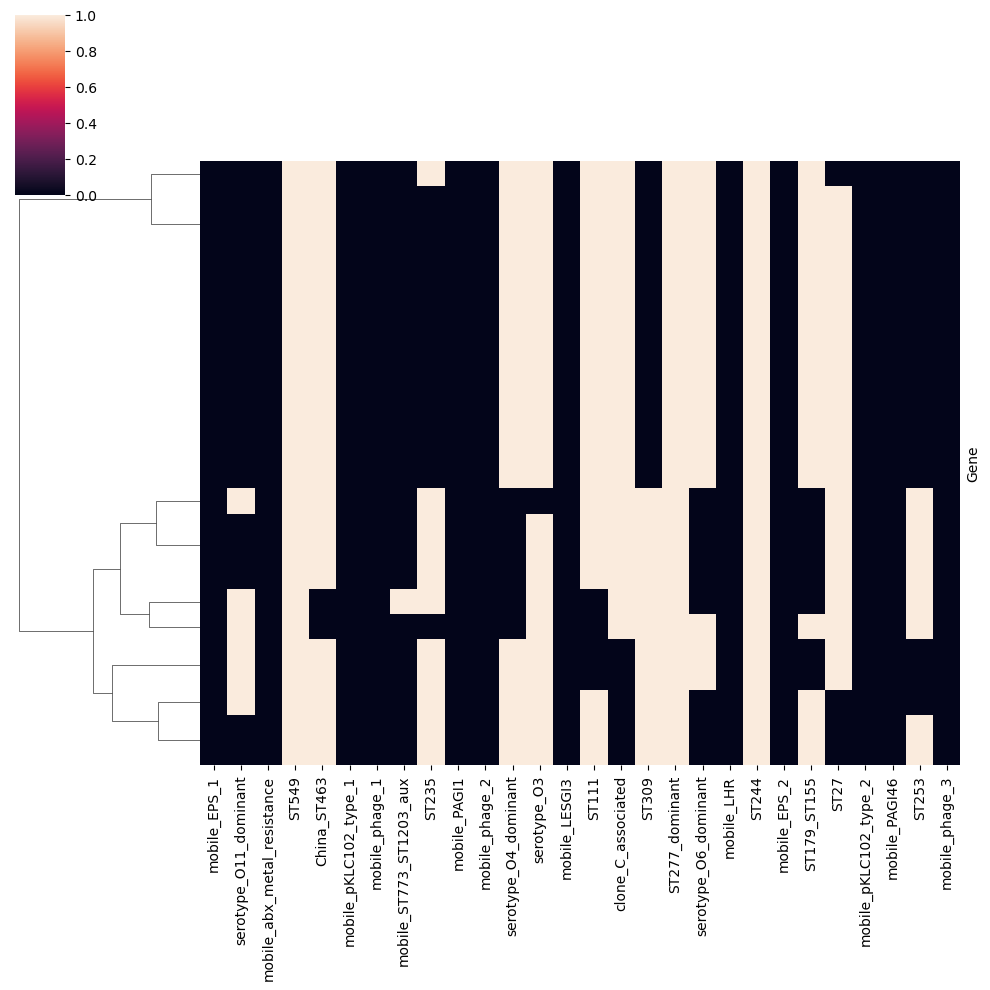

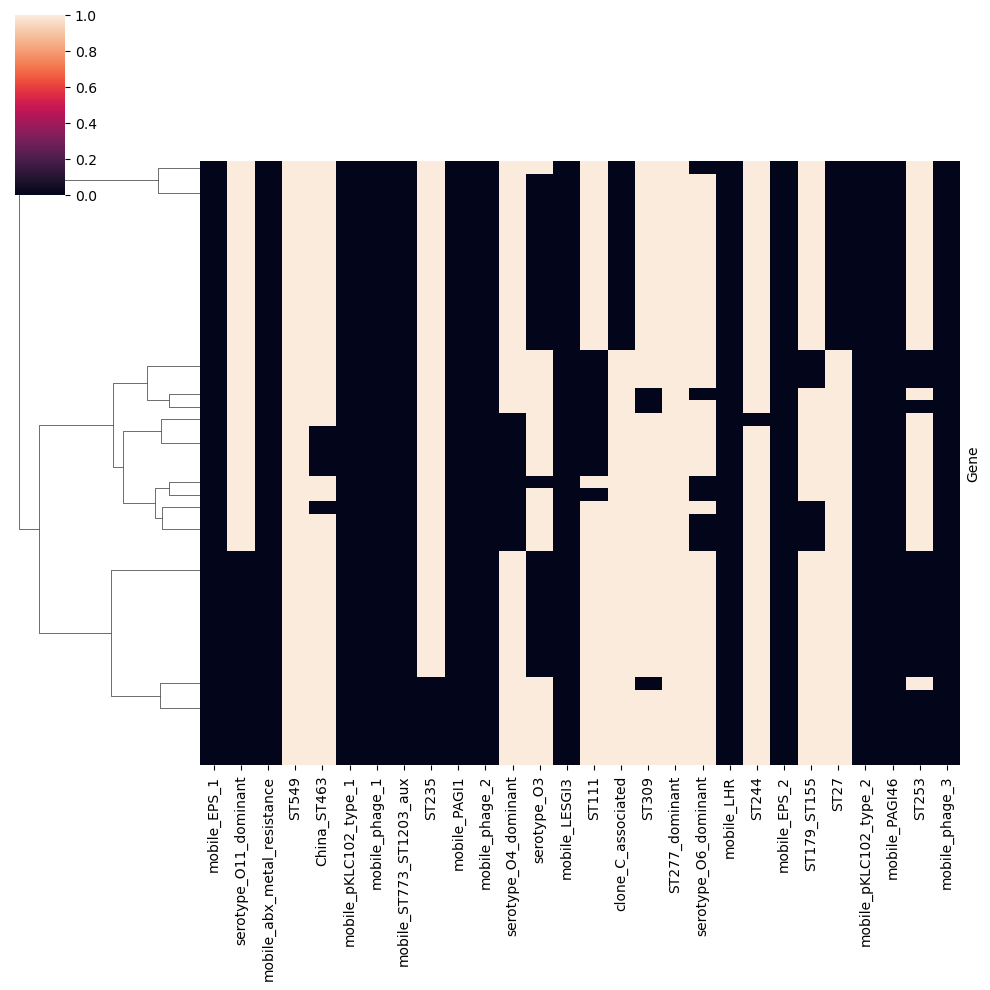

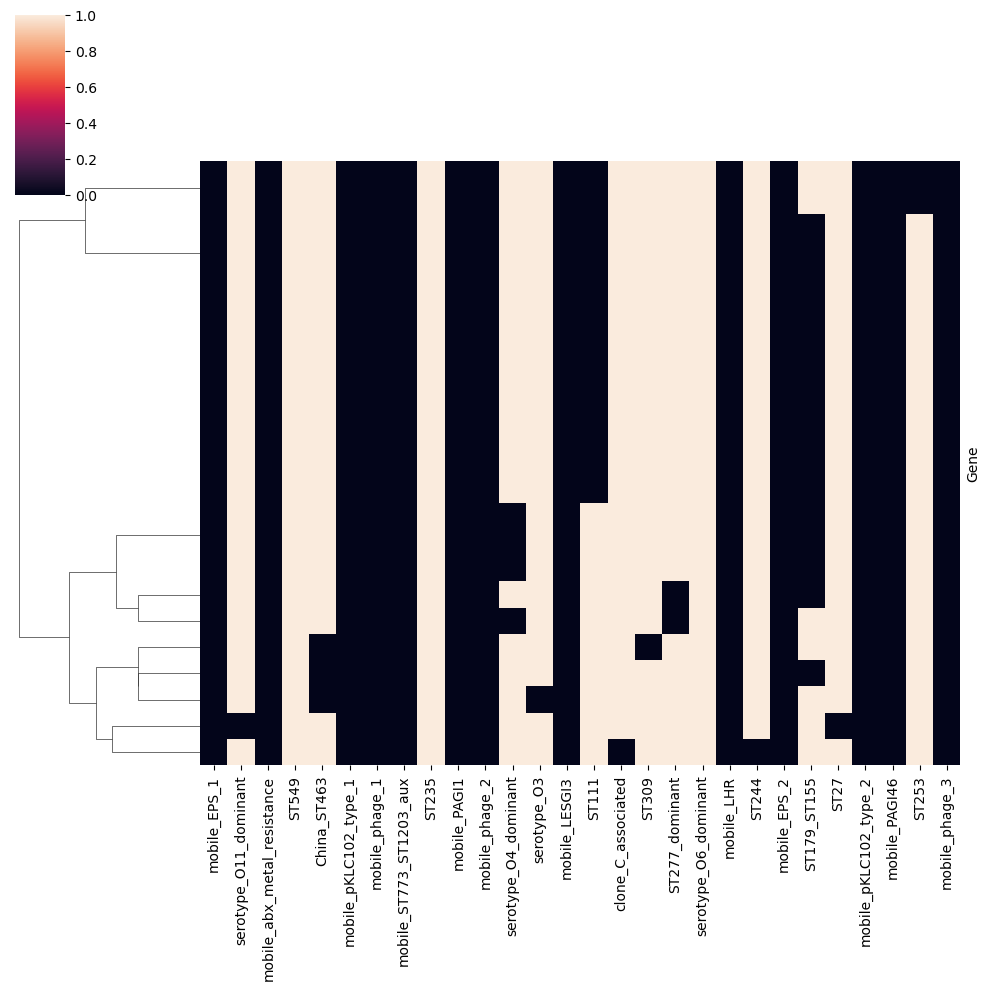

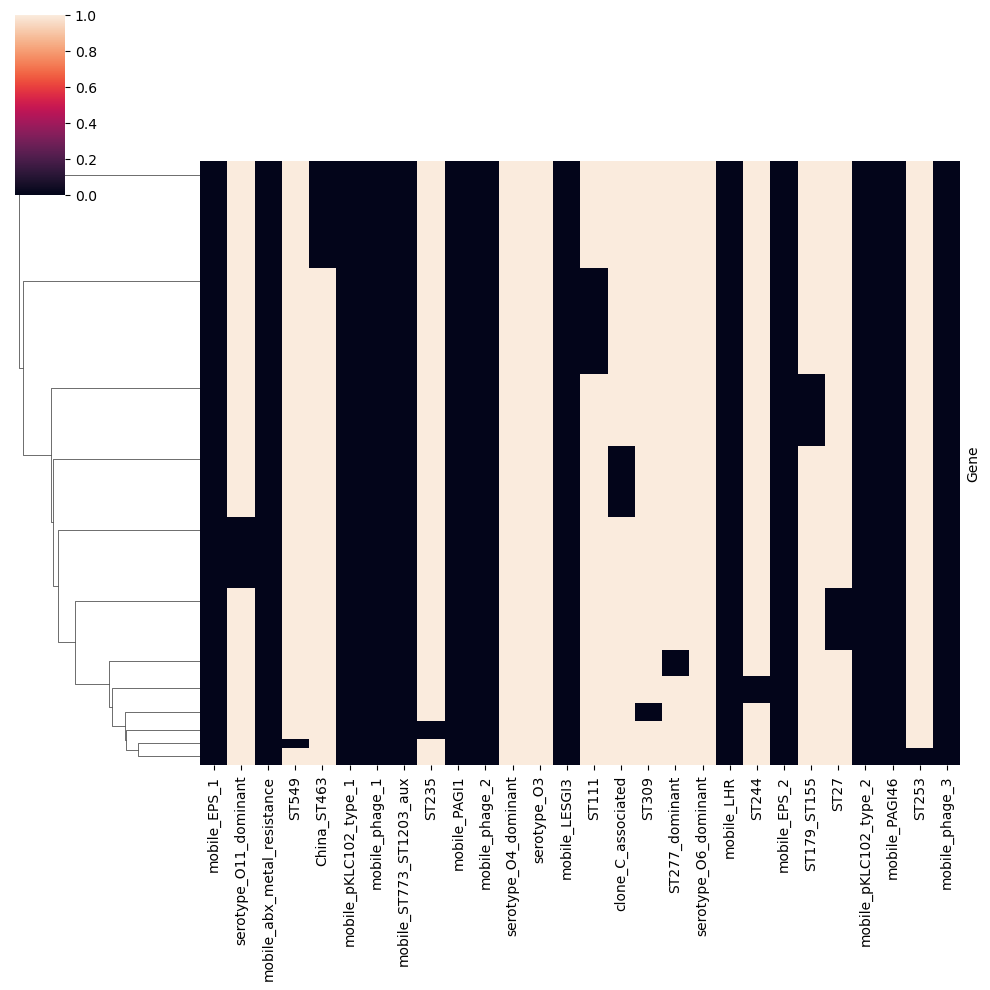

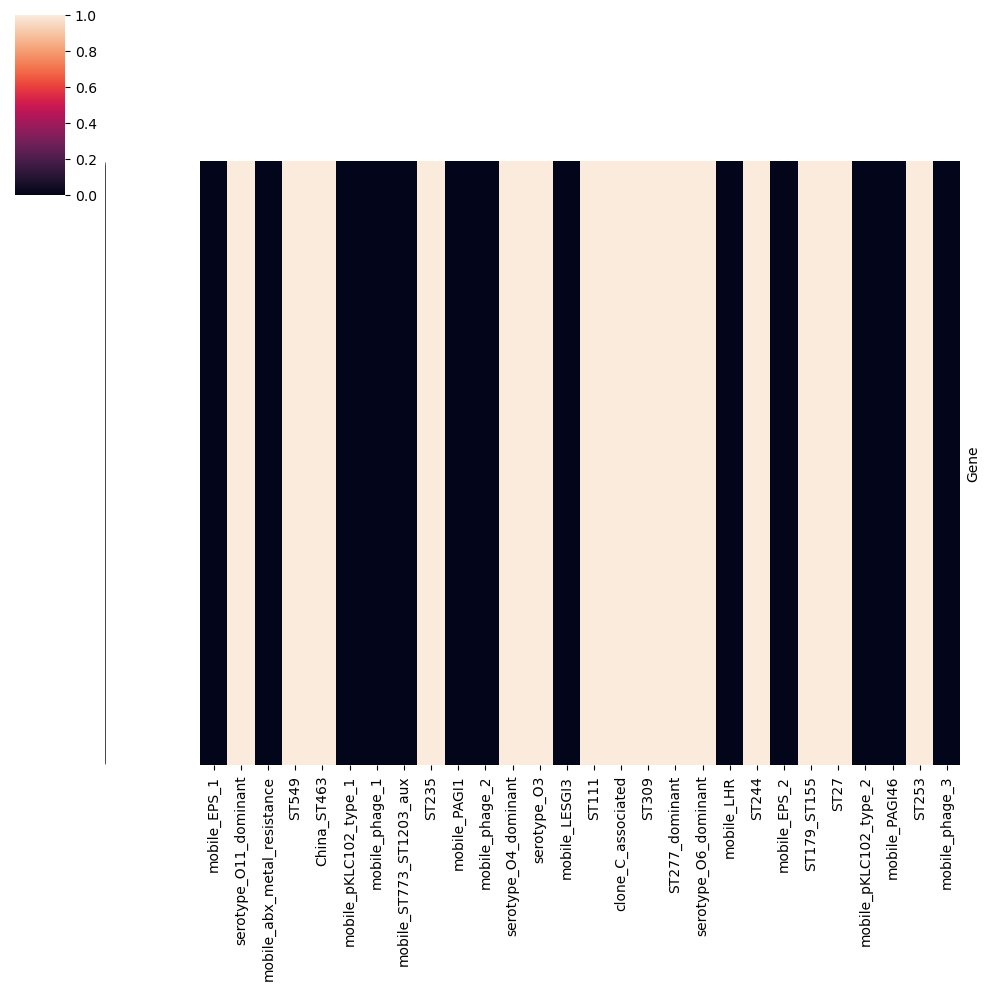

In [8]:
phylon_order = g_bin.data2d.columns.to_list()

gene_order = []

# Add in zero-phylon genes
zero_cond = L_binarized.sum(axis=1) == 0
gene_order.extend(L_binarized[zero_cond].index)

# Add in single-phylon genes
for phylon in phylon_order:
    single_cond = L_binarized.sum(axis=1) == 1
    inPhylon = L_binarized[phylon] == 1
    gene_order.extend(L_binarized[inPhylon & single_cond].index)

# Add in poly-phylon genes
for num_active_phylons in trange(2, int(L_binarized.sum(axis=1).max())+1):
    num_cond = L_binarized.sum(axis=1) == num_active_phylons
    gg = sns.clustermap(L_binarized[num_cond], method='ward', metric='euclidean', col_cluster=False, yticklabels=False);
    gene_order.extend(gg.data2d.index)

/mnt/craig/pan_phylon/P_aeruginosa/heera-jupyterlab/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


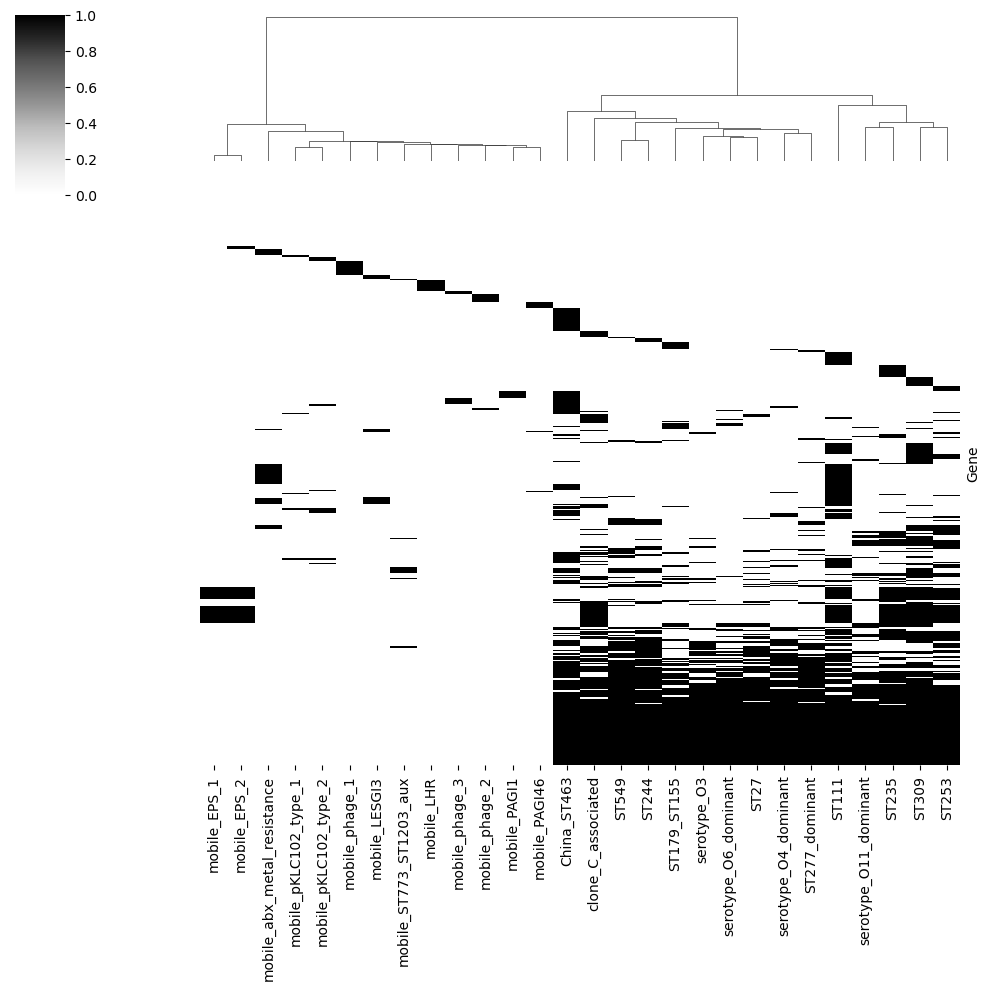

In [9]:
# Main sorted clustermap

g = sns.clustermap(
    L_binarized.loc[gene_order],
    method='ward',
    metric='euclidean',
    row_cluster=False,
    yticklabels=False,
    cmap='Greys'
)

## Figure 3C

In [10]:
phylon_order = g_bin.data2d.columns.to_list()

In [29]:
mobile_phylons = ['mobile_EPS_1',
                 'mobile_EPS_2',
                 'mobile_abx_metal_resistance',
                 'mobile_pKLC102_type_1',
                 'mobile_pKLC102_type_2',
                 'mobile_phage_1',
                 'mobile_LESGI3',
                 'mobile_ST773_ST1203_aux',
                 'mobile_LHR',
                 'mobile_phage_3',
                 'mobile_phage_2',
                 'mobile_PAGI1',
                 'mobile_PAGI46']

taxonomic_phylons = ['China_ST463',
                     'clone_C_associated',
                     'ST549',
                     'ST244',
                     'ST179_ST155',
                     'serotype_O3',
                     'serotype_O6_dominant',
                     'ST27',
                     'serotype_O4_dominant',
                     'ST277_dominant',
                     'ST111',
                     'serotype_O11_dominant',
                     'ST235',
                     'ST309',
                     'ST253']

In [13]:
strain_order = []
unchar_strain_order = []


# zero-phylon strains
noPhylon = A_binarized.sum() == 0
strain_order.extend(A_binarized.sum()[noPhylon].index.tolist())

# strain lists
single_phylon_strains = A_binarized.sum()[A_binarized.sum() == 1].index
multi_phylon_strains = A_binarized.sum()[A_binarized.sum() > 1].index

for phylon in phylon_order:
    # if 'unchar' in phylon:
    if phylon in mobile_phylons:
        continue
    else:
        phylon_aff_binarized_single = A_binarized.loc[phylon, single_phylon_strains]
        phylon_aff_binarized_multi = A_binarized.loc[phylon, multi_phylon_strains]
    
        inPhylon_single = phylon_aff_binarized_single == 1
        inPhylon_multi = phylon_aff_binarized_multi == 1
    
        list1 = phylon_aff_binarized_single[inPhylon_single].index.tolist()
        list2 = phylon_aff_binarized_multi[inPhylon_multi].index.tolist()
        new_list2 = list(set(list2) - set(strain_order)) # ensures no double-counting
        
        strain_order.extend(list1)
        strain_order.extend(new_list2)

for phylon in phylon_order: # must be done after the first loop
    # if 'unchar' in phylon:
    if phylon in mobile_phylons:
        phylon_aff_binarized_single = A_binarized.loc[phylon, single_phylon_strains]
        phylon_aff_binarized_multi = A_binarized.loc[phylon, multi_phylon_strains]
    
        inPhylon_single = phylon_aff_binarized_single == 1
        inPhylon_multi = phylon_aff_binarized_multi == 1
    
        list1 = phylon_aff_binarized_single[inPhylon_single].index.tolist()
        list2 = phylon_aff_binarized_multi[inPhylon_multi].index.tolist()
        new_list1 = list(set(list1) - set(strain_order)) # ensures no double-counting
        new_list2 = list(set(list2) - set(strain_order)) # ensures no double-counting

        
        strain_order.extend(new_list1)
        strain_order.extend(new_list2)


strain_order += unchar_strain_order

len(strain_order)

1317

In [14]:
strain_to_non_mobile = {}

for phylon in taxonomic_phylons:
    strains = A_binarized.columns[A_binarized.loc[phylon] == 1]
    for s in strains:
        if s not in strain_to_non_mobile:  # prevent overwriting
            strain_to_non_mobile[s] = phylon

In [30]:
palette = sns.color_palette("tab20", len(taxonomic_phylons))
phylon_to_color = dict(zip(taxonomic_phylons, palette))

In [16]:
data = A_binarized.loc[phylon_order, strain_order]

color_matrix = np.zeros((data.shape[0], data.shape[1], 3))  # RGB

for i, phylon in enumerate(data.index):
    for j, strain in enumerate(data.columns):
        if data.iloc[i, j] == 1:
            if strain in strain_to_non_mobile:
                color_matrix[i, j] = phylon_to_color[strain_to_non_mobile[strain]]
            else:
                color_matrix[i, j] = [0.8, 0.8, 0.8]  # fallback (e.g., mobile-only)
        else:
            color_matrix[i, j] = [1, 1, 1]  # white for absence

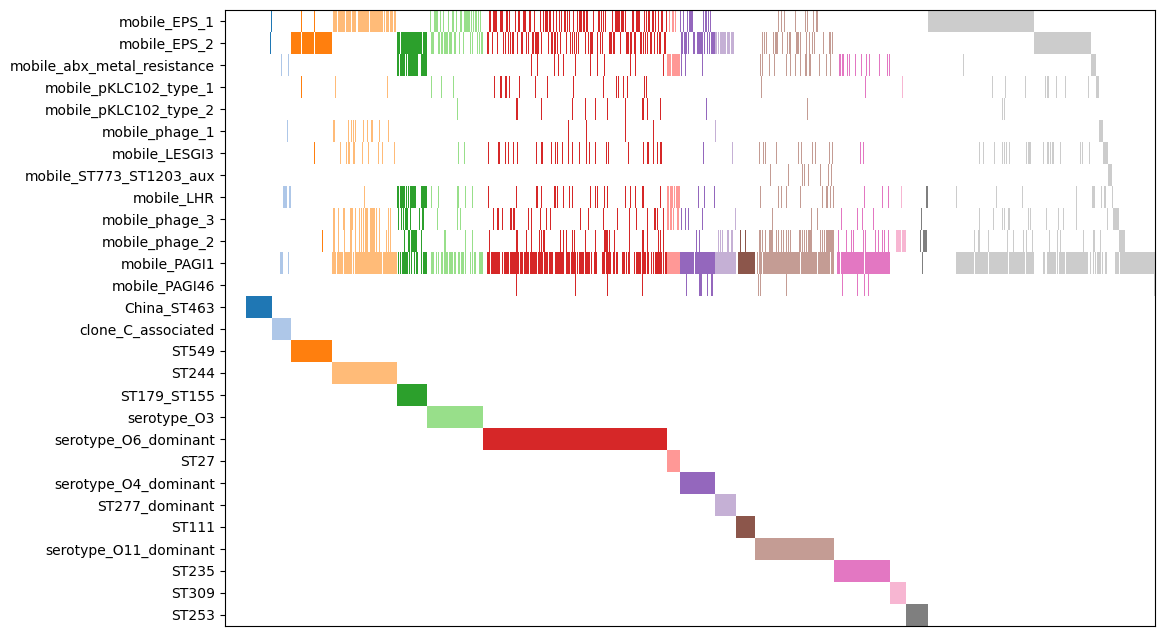

In [26]:
plt.figure(figsize=(12, 8))
plt.imshow(color_matrix, 
           aspect='auto', 
           interpolation='nearest'
          )

plt.yticks(range(len(data.index)), data.index)
plt.xticks([])

plt.show()

<BarContainer object of 28 artists>

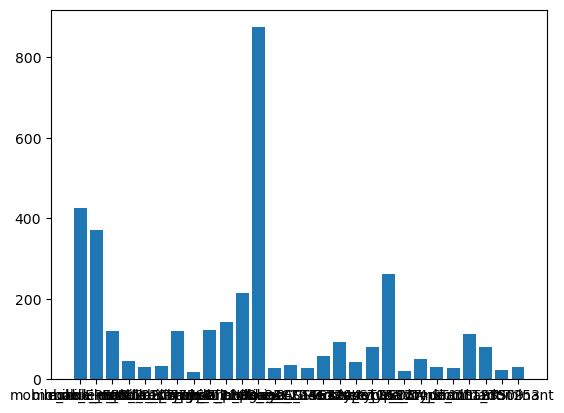

In [27]:
plt.bar(A_binarized.loc[phylon_order].sum(axis = 1).index, A_binarized.loc[phylon_order].sum(axis = 1).values)

# Figure 4
Created using Illustrator

# Figure 5

<Axes: >

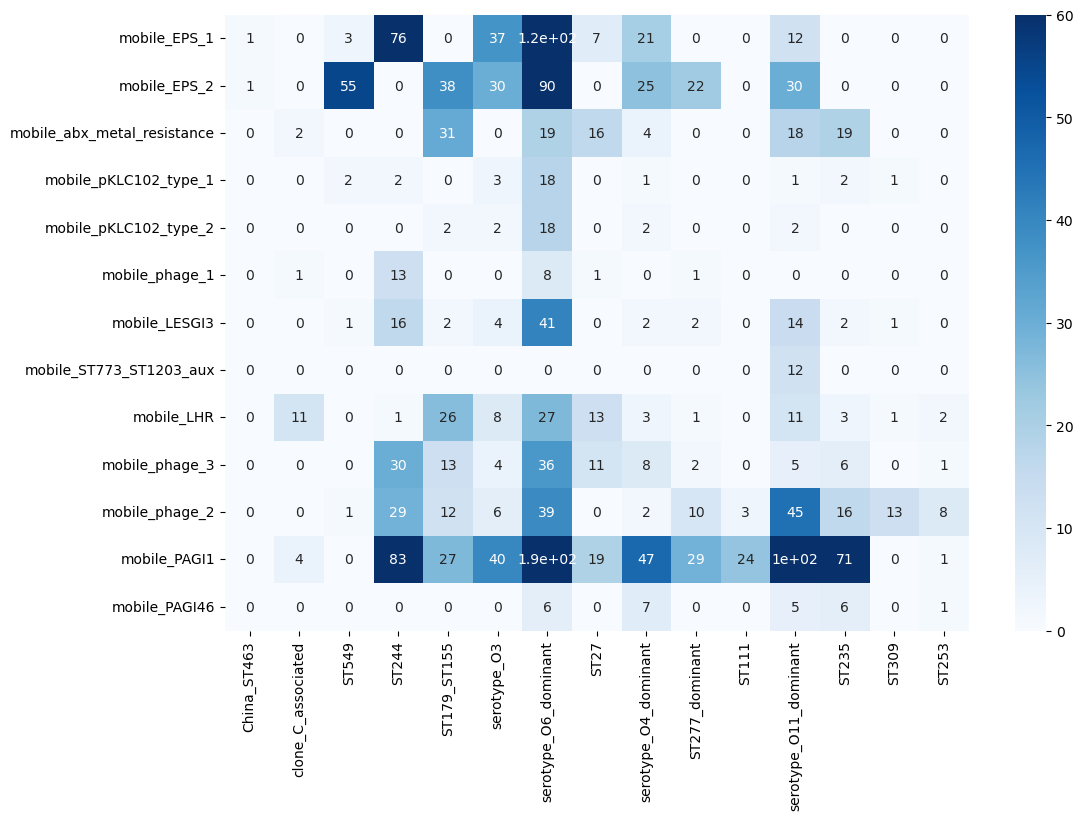

In [31]:
dist_df = pd.DataFrame(
    0,
    index=mobile_phylons,
    columns=taxonomic_phylons
)

for mobile in mobile_phylons:

    mobile_strains = A_binarized.columns[
        A_binarized.loc[mobile] == 1
    ]

    for tax in taxonomic_phylons:

        tax_strains = A_binarized.columns[
            A_binarized.loc[tax] == 1
        ]

        overlap = len(
            set(mobile_strains) & set(tax_strains)
        )

        dist_df.loc[mobile, tax] = overlap

plt.figure(figsize=(12,8))

sns.heatmap(
    dist_df,
    cmap="Blues",
    annot = True,
    vmax = 60
)

<BarContainer object of 15 artists>

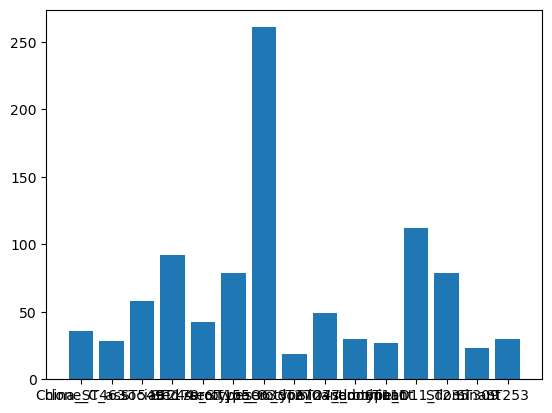

In [33]:
plt.bar(A_binarized.loc[taxonomic_phylons].sum(axis = 1).index, A_binarized.loc[taxonomic_phylons].sum(axis = 1).values)

## Figure 5B

In [48]:
metadata = metadata.set_index('genome_id')

In [51]:
for idx in metadata.loc[metadata.isolation_source_l1 == 'environment'].index:
    if metadata.loc[idx, 'isolation_source_l2'] == 'other':
        metadata.loc[idx, 'isolation_source_l2'] = 'env_other'
for idx in metadata.loc[metadata.isolation_source_l1 == 'other'].index:
    if metadata.loc[idx, 'isolation_source_l2'] == 'other':
        metadata.loc[idx, 'isolation_source_l2'] = 'other_other'

<Axes: >

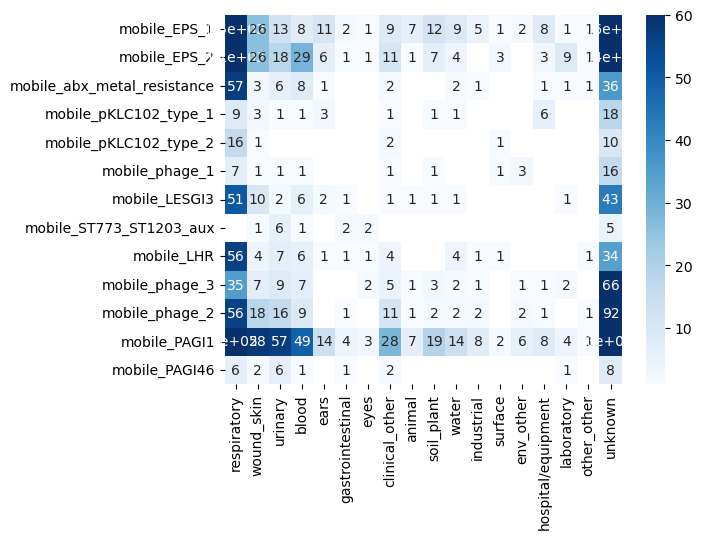

In [52]:
metadata_df = pd.DataFrame(index = mobile_phylons)

for phylon in metadata_df.index:
    isolation_source = metadata.loc[A_binarized.T.loc[A_binarized.loc[phylon] == 1].index].isolation_source_l2.value_counts()
    for iso in isolation_source.index:
        metadata_df.loc[phylon, iso] = isolation_source.loc[iso]

metadata_df = metadata_df[['respiratory', 'wound_skin','urinary', 'blood','ears',
                            'gastrointestinal', 'eyes','clinical_other','animal', 'soil_plant','water',
                            'industrial', 'surface','env_other','hospital/equipment','laboratory', 'other_other','unknown']]

sns.heatmap(metadata_df, cmap = 'Blues', annot = True, yticklabels = True, vmax = 60)

<BarContainer object of 13 artists>

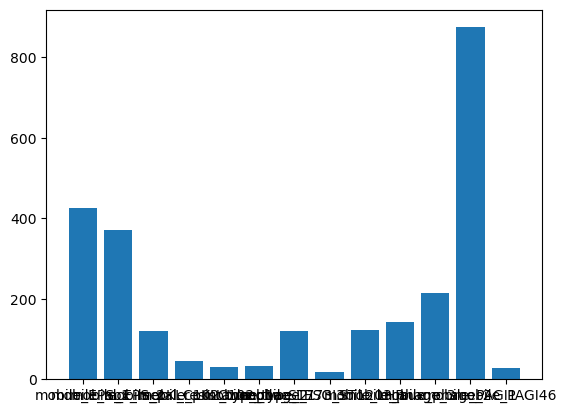

In [53]:
plt.bar(A_binarized.loc[mobile_phylons].sum(axis = 1).index, A_binarized.loc[mobile_phylons].sum(axis = 1).values)

# Figure 6
Figure 6A was generated using CGView
Code for Figure 6B can be found in LESGIs.R